In [38]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [39]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [40]:
ticker = 'SPYG'
df = yf.download(ticker, period='max')

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [41]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-10-02,18.304739,18.304739,18.304739,18.304739,2000
2000-10-03,18.091068,18.091068,18.091068,18.091068,2000
2000-10-04,18.091068,18.091068,18.091068,18.091068,0
2000-10-05,17.877392,17.877392,17.877392,17.877392,2000
2000-10-06,17.877392,17.877392,17.877392,17.877392,0
...,...,...,...,...,...
2026-07-30,115.470001,115.639999,113.790001,114.000000,5694100
2026-07-31,117.139999,117.519997,115.199997,116.669998,6659600
2026-08-03,119.660004,120.029999,117.290001,117.440002,2161900


<Axes: xlabel='Date'>

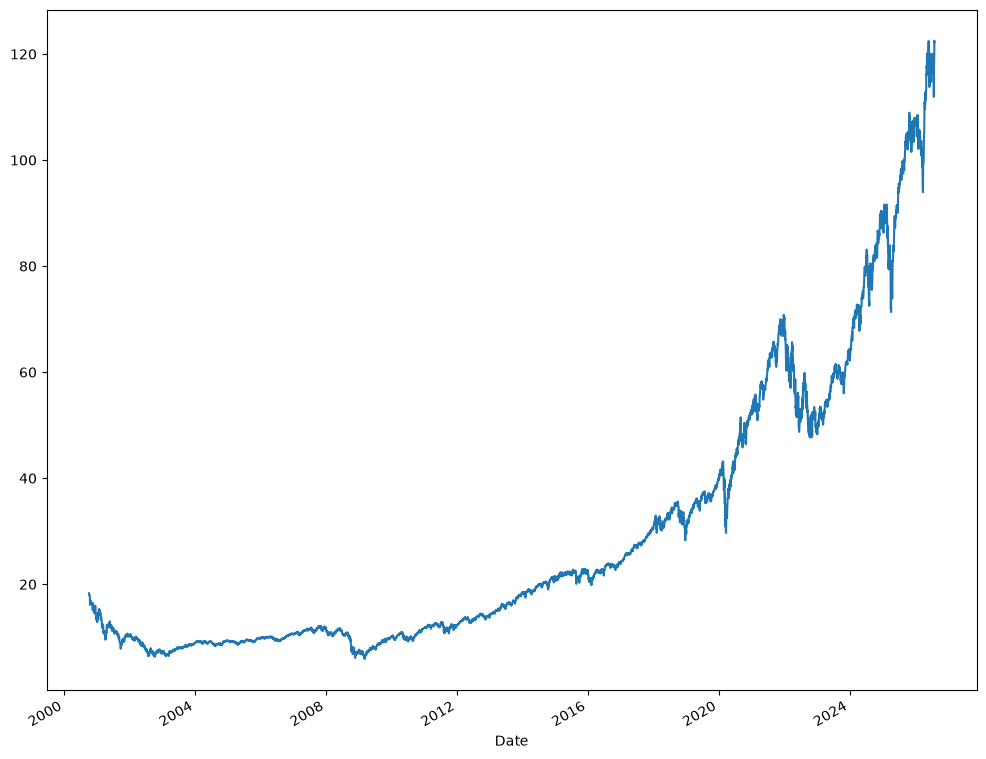

In [42]:
df.Close.plot(figsize=(12,10))

In [43]:
data = df[['Close', 'High', 'Low', 'Volume']].copy()

data['Return'] = df['Close'].pct_change()
data['LogVolume'] = np.log(df['Volume'] + 1)

data['MA10_ratio'] = df['Close'] / df['Close'].rolling(10).mean() - 1
data['MA50_ratio'] = df['Close'] / df['Close'].rolling(50).mean() - 1
data['Volatility10'] = data['Return'].rolling(10).std()
data['HighLowRange'] = (df['High'] - df['Low']) / df['Close']

delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

data = data.replace([np.inf, -np.inf], np.nan).dropna()
print(f"{len(data)} rows after merging and dropping NaNs, spanning {data.index.min().date()} to {data.index.max().date()}")
data.head()

6449 rows after merging and dropping NaNs, spanning 2000-12-11 to 2026-08-05


Price,Close,High,Low,Volume,Return,LogVolume,MA10_ratio,MA50_ratio,Volatility10,HighLowRange,RSI
Date,,,,,,,,,,,
2000-12-11,15.930577,16.120510,15.930577,15200,0.050078,9.629116,0.052714,-0.021838,0.030063,0.011923,58.566768
2000-12-12,15.859361,15.989939,15.716911,1600,-0.004470,7.378384,0.042610,-0.023277,0.027276,0.017216,57.492270
2000-12-13,15.420137,16.049289,15.420137,1200,-0.027695,7.090910,0.011446,-0.047193,0.029222,0.040801,53.107350
2000-12-14,15.277699,15.455761,15.277699,4400,-0.009237,8.389587,-0.002170,-0.052701,0.027332,0.011655,51.366257
2000-12-15,14.486673,14.486673,14.379804,101600,-0.051777,11.528809,-0.053714,-0.097956,0.032590,0.007377,37.852195


In [44]:
feature_cols = [
    'Return', 'LogVolume', 'MA10_ratio', 'MA50_ratio',
    'Volatility10', 'HighLowRange', 'RSI'
]
target_col = 'Return'
seq_length = 20

def make_sequences(frame, seq_length):
    X, y = [], []
    feat = frame[feature_cols].values
    tgt = frame[target_col].values
    for i in range(len(frame) - seq_length):
        X.append(feat[i:i + seq_length])
        y.append(tgt[i + seq_length])
    return np.array(X), np.array(y)

In [45]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.drop(out[:, -1, :])
        out = self.fc(out)
        return out

In [46]:
def train_model(model, train_loader, X_val, y_val, num_epochs=100, patience=10, lr=0.001):
    criterion = nn.HuberLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_val_loss

In [47]:
def prepare_fold(data, train_end, test_end, seq_length):
    train_df = data.iloc[:train_end]
    # include seq_length days of lookback before the test window so the first test
    # sequences have enough history
    test_df = data.iloc[max(0, train_end - seq_length):test_end]

    scaler = StandardScaler()
    train_scaled = train_df.copy()
    test_scaled = test_df.copy()
    train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_scaled[feature_cols] = scaler.transform(test_df[feature_cols])

    X_train, y_train = make_sequences(train_scaled, seq_length)
    X_test, y_test = make_sequences(test_scaled, seq_length)

    return X_train, y_train, X_test, y_test, scaler, test_df

In [48]:
n_folds = 5
test_frac = 0.08
n = len(data)
test_size = int(n * test_frac)

fold_results = []
last_fold_plot_data = None

for fold in range(n_folds):
    train_end = n - (n_folds - fold) * test_size
    test_end = train_end + test_size
    if train_end < 500:
        continue

    X_train, y_train, X_test, y_test, fold_scaler, test_df = prepare_fold(data, train_end, test_end, seq_length)

    val_cut = int(len(X_train) * 0.85)
    X_tr, y_tr = X_train[:val_cut], y_train[:val_cut]
    X_val, y_val = X_train[val_cut:], y_train[val_cut:]

    X_tr_t = torch.from_numpy(X_tr).float()
    y_tr_t = torch.from_numpy(y_tr).float().unsqueeze(1)
    X_val_t = torch.from_numpy(X_val).float().to(device)
    y_val_t = torch.from_numpy(y_val).float().unsqueeze(1).to(device)
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_test_t = torch.from_numpy(y_test).float().unsqueeze(1).to(device)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

    model = PredictionModel(input_dim=len(feature_cols), hidden_dim=32, num_layers=2, output_dim=1, dropout=0.2).to(device)
    model, _ = train_model(model, train_loader, X_val_t, y_val_t, num_epochs=100, patience=10)

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).cpu().numpy()
    y_true = y_test_t.cpu().numpy()

    naive_pred = np.zeros_like(y_true)
    model_rmse = root_mean_squared_error(y_true, y_pred)
    naive_rmse = root_mean_squared_error(y_true, naive_pred)
    dir_acc = (np.sign(y_pred) == np.sign(y_true)).mean()

    fold_results.append({
        'fold': fold,
        'train_size': train_end,
        'model_rmse': model_rmse,
        'naive_rmse': naive_rmse,
        'directional_accuracy': dir_acc
    })
    print(f"Fold {fold}: train_size={train_end}, model_rmse={model_rmse:.5f}, naive_rmse={naive_rmse:.5f}, dir_acc={dir_acc:.2%}")

    last_fold_plot_data = dict(
        model=model, scaler=fold_scaler, test_df=test_df,
        X_test_t=X_test_t, y_test_t=y_test_t, y_pred=y_pred, y_true=y_true
    )

results_df = pd.DataFrame(fold_results)
results_df

Fold 0: train_size=3874, model_rmse=0.53473, naive_rmse=0.53771, dir_acc=59.22%
Fold 1: train_size=4389, model_rmse=1.20838, naive_rmse=1.22637, dir_acc=49.13%
Fold 2: train_size=4904, model_rmse=1.05595, naive_rmse=1.04766, dir_acc=53.79%
Fold 3: train_size=5419, model_rmse=0.87125, naive_rmse=0.87220, dir_acc=53.40%
Fold 4: train_size=5934, model_rmse=1.01773, naive_rmse=1.01589, dir_acc=56.12%


,fold,train_size,model_rmse,naive_rmse,directional_accuracy
0,0,3874,0.534730,0.537714,0.592233
1,1,4389,1.208385,1.226369,0.491262
2,2,4904,1.055951,1.047664,0.537864
3,3,5419,0.871245,0.872200,0.533981
4,4,5934,1.017731,1.015886,0.561165


Average directional accuracy across folds: 54.33%  (50% = coin flip)
Average model RMSE:  0.93761
Average naive RMSE:  0.93997


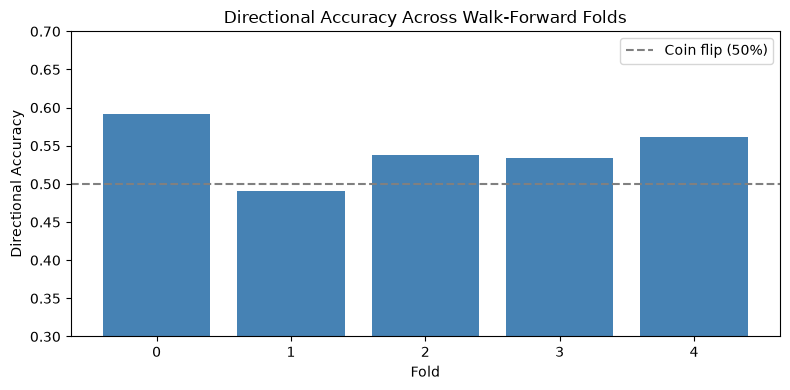

In [49]:
print(f"Average directional accuracy across folds: {results_df['directional_accuracy'].mean():.2%}  (50% = coin flip)")
print(f"Average model RMSE:  {results_df['model_rmse'].mean():.5f}")
print(f"Average naive RMSE:  {results_df['naive_rmse'].mean():.5f}")

plt.figure(figsize=(8, 4))
plt.bar(results_df['fold'].astype(str), results_df['directional_accuracy'], color='steelblue')
plt.axhline(0.5, color='gray', linestyle='--', label='Coin flip (50%)')
plt.ylim(0.3, 0.7)
plt.ylabel('Directional Accuracy')
plt.xlabel('Fold')
plt.title('Directional Accuracy Across Walk-Forward Folds')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
split_idx = int(len(data) * 0.9)
train_final = data.iloc[:split_idx]
val_final = data.iloc[split_idx:]

final_scaler = StandardScaler()
final_scaler.fit(train_final[feature_cols])

train_final_scaled = train_final.copy()
val_final_scaled = val_final.copy()
train_final_scaled[feature_cols] = final_scaler.transform(train_final[feature_cols])
val_final_scaled[feature_cols] = final_scaler.transform(val_final[feature_cols])

X_tr, y_tr = make_sequences(train_final_scaled, seq_length)
X_val, y_val = make_sequences(val_final_scaled, seq_length)

X_tr_t = torch.from_numpy(X_tr).float()
y_tr_t = torch.from_numpy(y_tr).float().unsqueeze(1)
X_val_t = torch.from_numpy(X_val).float().to(device)
y_val_t = torch.from_numpy(y_val).float().unsqueeze(1).to(device)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

target_idx = feature_cols.index(target_col)
def inverse_target(y_scaled, scaler=final_scaler):
    return y_scaled * scaler.scale_[target_idx] + scaler.mean_[target_idx]

In [51]:
n_ensemble = 5
ensemble_models = []

for seed in range(n_ensemble):
    torch.manual_seed(seed)
    m = PredictionModel(input_dim=len(feature_cols), hidden_dim=32, num_layers=2, output_dim=1, dropout=0.2).to(device)
    m, val_loss = train_model(m, train_loader, X_val_t, y_val_t, num_epochs=100, patience=10)
    ensemble_models.append(m)
    print(f"Ensemble member {seed}: val_loss={val_loss:.5f}")

Ensemble member 0: val_loss=0.34359
Ensemble member 1: val_loss=0.34196
Ensemble member 2: val_loss=0.34033
Ensemble member 3: val_loss=0.33670
Ensemble member 4: val_loss=0.33984


In [52]:
val_preds = np.mean([m(X_val_t).detach().cpu().numpy() for m in ensemble_models], axis=0)
val_true = y_val_t.cpu().numpy()

ens_rmse = root_mean_squared_error(val_true, val_preds)
naive_rmse_val = root_mean_squared_error(val_true, np.zeros_like(val_true))
ens_dir_acc = (np.sign(val_preds) == np.sign(val_true)).mean()

print(f"Ensemble RMSE:              {ens_rmse:.5f}")
print(f"Naive RMSE (predict 0):     {naive_rmse_val:.5f}")
print(f"Ensemble directional accuracy: {ens_dir_acc:.2%}  (50% = coin flip)")

Ensemble RMSE:              0.95151
Naive RMSE (predict 0):     0.96520
Ensemble directional accuracy: 55.84%  (50% = coin flip)


In [53]:
last_seq = final_scaler.transform(data[feature_cols].iloc[-seq_length:])
last_seq_t = torch.from_numpy(last_seq).float().unsqueeze(0).to(device)

with torch.no_grad():
    member_preds_scaled = [m(last_seq_t).cpu().numpy().item() for m in ensemble_models]

member_preds_ret = [inverse_target(p) for p in member_preds_scaled]
pred_return = np.mean(member_preds_ret)
pred_std = np.std(member_preds_ret)

last_close = data['Close'].iloc[-1]
predicted_price = last_close * (1 + pred_return)

print(f"Last close:                     {last_close:.2f}")
print(f"Ensemble predicted return:      {pred_return:.4%}")
print(f"Ensemble disagreement (std):    {pred_std:.4%}")
print(f"Ensemble predicted price:       {predicted_price:.2f}")

Last close:                     122.25
Ensemble predicted return:      0.0653%
Ensemble disagreement (std):    0.0378%
Ensemble predicted price:       122.33


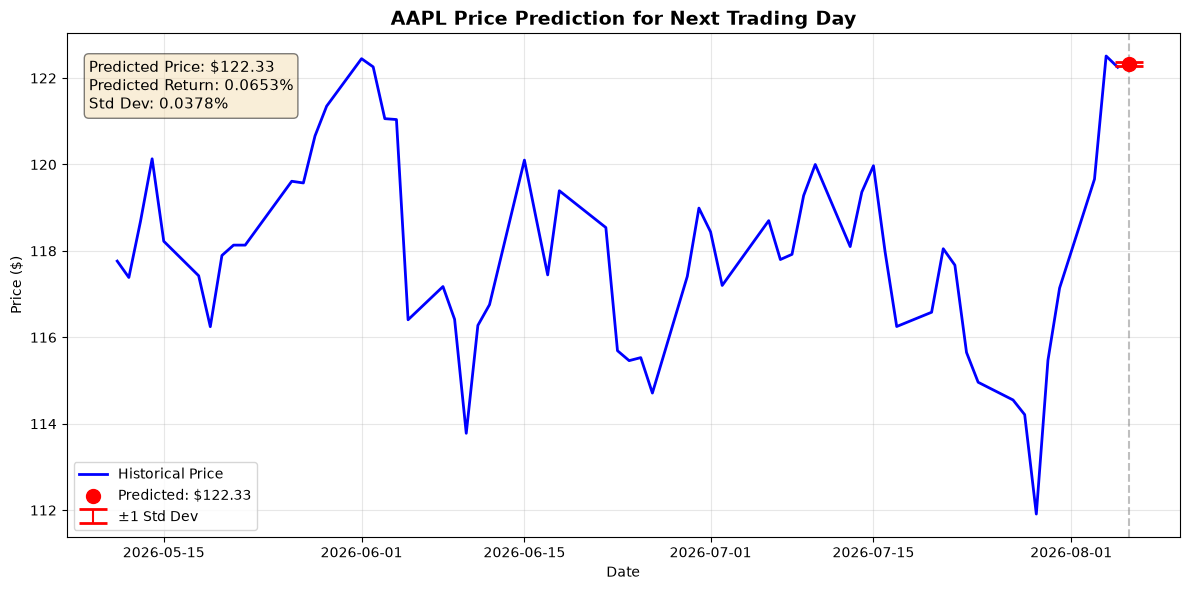


NEXT DAY PRICE PREDICTION
Last Close:              $122.25
Predicted Return:        0.0653%
Predicted Price:         $122.33
Prediction Std Dev:      $0.05
Prediction Range (1σ):   $122.28 - $122.38


In [55]:
# ====== PLOT: FINAL PREDICTION FOR NEXT DAY ======

# Predict next day's price
last_seq = final_scaler.transform(data[feature_cols].iloc[-seq_length:])
last_seq_t = torch.from_numpy(last_seq).float().unsqueeze(0).to(device)

with torch.no_grad():
    member_preds_scaled = np.array([m(last_seq_t).cpu().numpy().item() for m in ensemble_models])

member_preds_ret = inverse_target(member_preds_scaled)
pred_return = np.mean(member_preds_ret)
pred_std = np.std(member_preds_ret)

last_close = data['Close'].iloc[-1]
predicted_price = last_close * (1 + pred_return)
price_std = last_close * pred_std

# Create a summary visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Show recent price history
lookback = 60
recent_dates = data.index[-lookback:]
recent_prices = data['Close'].values[-lookback:]

ax.plot(recent_dates, recent_prices, 'b-', label='Historical Price', linewidth=2)

# Add the prediction
next_date = recent_dates[-1] + pd.Timedelta(days=1)
ax.scatter(next_date, predicted_price, color='red', s=100, zorder=5, label=f'Predicted: ${predicted_price:.2f}')
ax.errorbar(next_date, predicted_price, yerr=price_std, fmt='none', 
            ecolor='red', capsize=10, capthick=2, label='±1 Std Dev')

# Add confidence interval shading
price_lower = predicted_price - price_std
price_upper = predicted_price + price_std
ax.fill_between([next_date], [price_lower], [price_upper], alpha=0.3, color='red')

# Add a vertical line at the prediction point
ax.axvline(x=next_date, color='gray', linestyle='--', alpha=0.5)

ax.set_title('AAPL Price Prediction for Next Trading Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Add annotation with prediction details
textstr = f'Predicted Price: ${predicted_price:.2f}\nPredicted Return: {pred_return:.4%}\nStd Dev: {pred_std:.4%}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("NEXT DAY PRICE PREDICTION")
print("="*60)
print(f"Last Close:              ${last_close:.2f}")
print(f"Predicted Return:        {pred_return:.4%}")
print(f"Predicted Price:         ${predicted_price:.2f}")
print(f"Prediction Std Dev:      ${price_std:.2f}")
print(f"Prediction Range (1σ):   ${predicted_price - price_std:.2f} - ${predicted_price + price_std:.2f}")
print("="*60)